In [35]:
import pandas as pd
import math

df = pd.read_csv('endurance_motec_export.csv')

In [2]:
print(df.columns)

Index(['Time', 'Car DigitalInput MSS PDOC Pin', 'Car DigitalInput MSS BMS Pin',
       'Car DigitalInput MSS BSPD Pin', 'Car DigitalInput MSS IMD Pin',
       'Car Data Driver ThrottlePressure', 'Car Data Motor MotorRPM',
       'Car AnalogInput BMS CellTempASensor',
       'Car AnalogInput BMS CellTempBSensor',
       'Car AnalogInput BMS CellTempCSensor', 'Car Data Battery PackSOC',
       'Car Data PDM LVBatteryVoltage', 'Car Data Battery BMSInternalTemp',
       'Car Data Inverter InverterTemp', 'Car Data Motor MotorTemp',
       'Car Data Inverter InverterLock', 'Car Data Driver Speed',
       'Car Data Water WaterTempOut', 'Car Data Driver SteeringAngle',
       'Car Data Driver FrontBrakePressure',
       'Car Data Driver RearBrakePressure',
       'Car Data Driver ThrottleDifference', 'Car Data Battery HotSpotTemp',
       'Car Data Water WaterPressureIn', 'Car Data Water WaterPressureOut',
       'Car Data Water WaterTempIn',
       'Car Data Battery PackInstantaneousVoltage',

$$ P = VI \\
   E = \int_{t_0}^{t_1} P(t) dt
   \approx \sum_{i}P(i)\Delta t_i
$$

In [36]:
def calcPowerUsage(df, t0=0, t1=float('inf')):
    filteredDf = df[(t1 >= df['Time']) & (df['Time'] >= t0)]

    #Factor of 100 as assuming both voltage and current are scaled by a factor of 10
    #So power is scaled by 100 (If curr data was in W car we be dq)
    filteredDf["Scaled Battery Power (W)"] = (filteredDf["Car Data Battery BatteryPower"] / 100)

    filteredDf["Delta Time (s)"] = filteredDf["Time"].diff().fillna(0)

    filteredDf["Power * dt"] = filteredDf["Scaled Battery Power (W)"] * filteredDf["Delta Time (s)"]
    #This is in (Ws)

    totalEnergy = filteredDf["Power * dt"].sum()

    #Conversion factor of Ws -> kWH
    CONVERSION = 3_600_600
    totalEnergyKWH = totalEnergy / CONVERSION

    print(f"Total Energy Usage = {totalEnergyKWH} kWh")
    return totalEnergyKWH



In [37]:
calcPowerUsage(df)

Total Energy Usage = 3.458830465672388 kWh


np.float64(3.458830465672388)

$$ P_\text{mechanical}=\tau\frac{2\pi RPM}{60} = \frac{ \pi \tau RPM}{30} $$



In [69]:
def calcEfficiency(df, t0=0, t1=float('inf')):
    filteredDf = df[(t1 >= df['Time']) & (df['Time'] >= t0)]

    #Factor of 100 as assuming both voltage and current are scaled by a factor of 10
    #So power is scaled by 100 (If curr data was in W car we be dq)
    filteredDf["Scaled Battery Power (W)"] = (filteredDf["Car Data Battery BatteryPower"] / 100)


    #Scaled by an additional factor of 10 to account for torque not being in Nm
    filteredDf["Mechanical Power"] =  abs(math.pi * filteredDf["Car Data Inverter InverterFDBTorque"] *  filteredDf["Car Data Motor MotorRPM"] / 300)

    #Ignoring when no (or little) power is being deployed
    filteredDf = filteredDf[(filteredDf['Scaled Battery Power (W)'] > 5000)].copy()

    filteredDf["Motor Efficiency"] = filteredDf["Mechanical Power"] / filteredDf["Scaled Battery Power (W)"]
   
    return filteredDf

In [72]:
import matplotlib.pyplot as plt
import numpy as np

In [70]:
fDf = calcEfficiency(df)

In [77]:
def createEfficiencyPlot(xName, yName):
    x = fDf[xName]
    y = fDf[yName]
    z = fDf["Motor Efficiency"]

    xbins = np.linspace(x.min(), x.max(), 10)
    ybins = np.linspace(y.min(), y.max(), 10)

    # Calculate mean efficiency in each rectangular bin
    sum_z, _, _ = np.histogram2d(x, y, bins=[xbins, ybins], weights=z)
    count, _, _ = np.histogram2d(x, y, bins=[xbins, ybins])

    mean_z = sum_z / count
    mean_z[count == 0] = np.nan

    plt.figure(figsize=(10, 7))

    plt.pcolormesh(
        xbins,
        ybins,
        mean_z.T,
        shading="auto",
        vmin=0,
        vmax=1.0
    )

    plt.colorbar(label="Motor Efficiency")

    plt.xlabel(xName)
    plt.ylabel(yName)
    plt.title(f"Motor Efficiency vs {xName} and {yName}")

    plt.show()

C:\Users\Toby Jenkin\AppData\Local\Temp\ipykernel_13860\847086421.py:13: RuntimeWarning: invalid value encountered in divide
  mean_z = sum_z / count


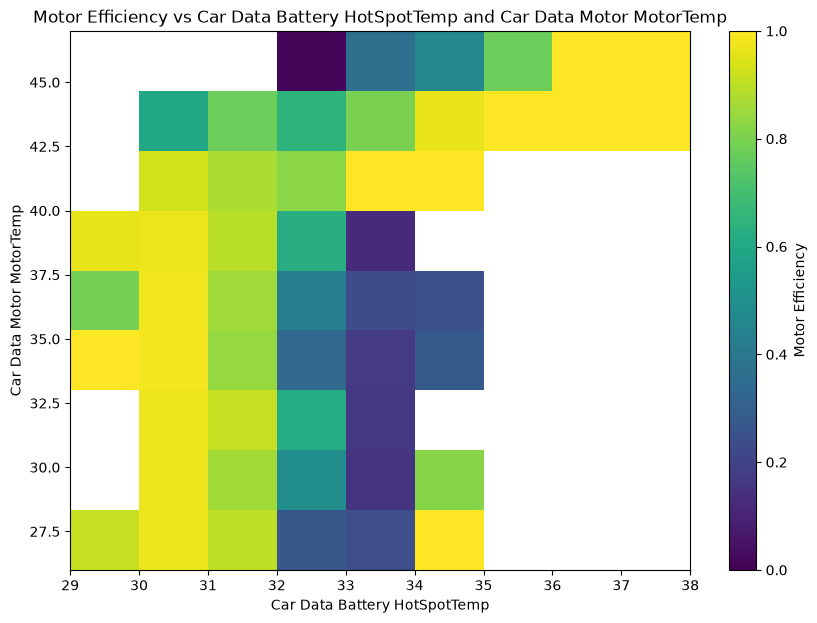

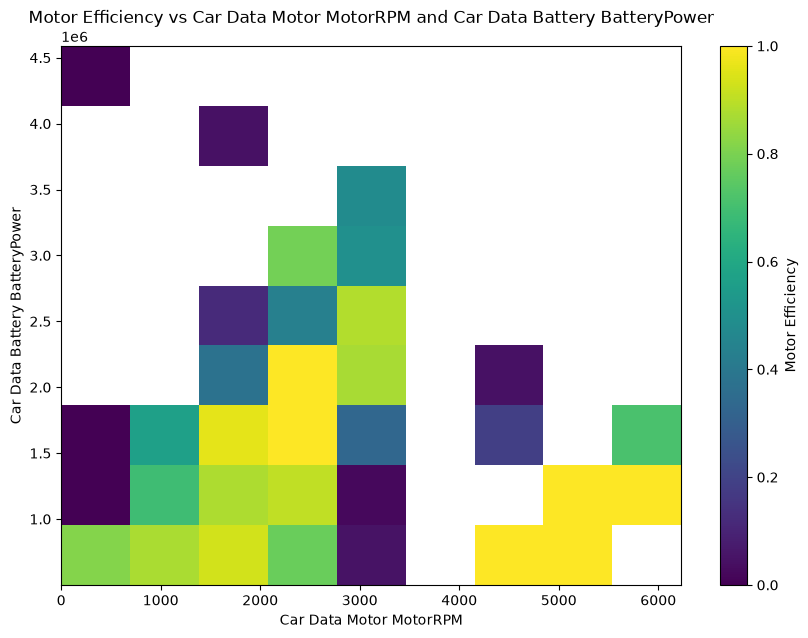

In [78]:
createEfficiencyPlot("Car Data Battery HotSpotTemp",
"Car Data Motor MotorTemp")
createEfficiencyPlot("Car Data Motor MotorRPM",
"Car Data Battery BatteryPower")